In [1]:
print("LungAI is ready!")

LungAI is ready!


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "chest_xray"

print(DATA_DIR)
print(DATA_DIR.exists())

/Users/user/Desktop/LungAI/data/chest_xray
True


In [3]:
from pathlib import Path

for split in ["train", "val", "test"]:
    normal = len(list((DATA_DIR / split / "NORMAL").glob("*")))
    pneumonia = len(list((DATA_DIR / split / "PNEUMONIA").glob("*")))
    
    print(f"{split.upper()}:")
    print(f"  NORMAL: {normal}")
    print(f"  PNEUMONIA: {pneumonia}")
    print(f"  TOTAL: {normal + pneumonia}")

TRAIN:
  NORMAL: 1341
  PNEUMONIA: 3875
  TOTAL: 5216
VAL:
  NORMAL: 8
  PNEUMONIA: 8
  TOTAL: 16
TEST:
  NORMAL: 234
  PNEUMONIA: 390
  TOTAL: 624


In [4]:
import matplotlib.pyplot as plt
from PIL import Image

normal_images = list((DATA_DIR / "train" / "NORMAL").glob("*.jpeg"))
pneumonia_images = list((DATA_DIR / "train" / "PNEUMONIA").glob("*.jpeg"))

normal_image = Image.open(normal_images[0])
pneumonia_image = Image.open(pneumonia_images[0])

print("Normal image size:", normal_image.size)
print("Pneumonia image size:", pneumonia_image.size)

Normal image size: (2359, 2234)
Pneumonia image size: (1048, 736)


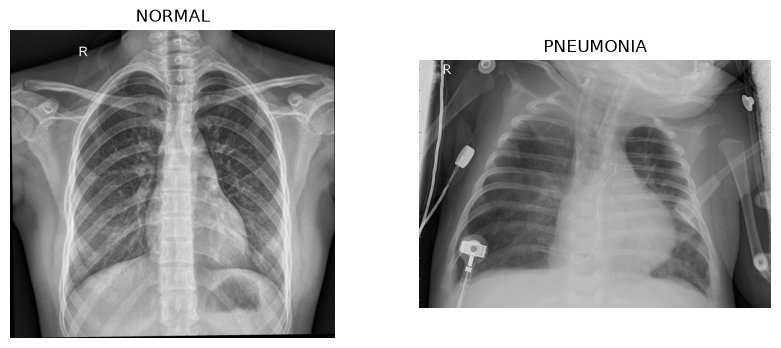

In [5]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(normal_image, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia_image, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

In [6]:
IMG_SIZE = (224, 224)

normal_resized = normal_image.resize(IMG_SIZE)
pneumonia_resized = pneumonia_image.resize(IMG_SIZE)

print("Normal:", normal_resized.size)
print("Pneumonia:", pneumonia_resized.size)

Normal: (224, 224)
Pneumonia: (224, 224)


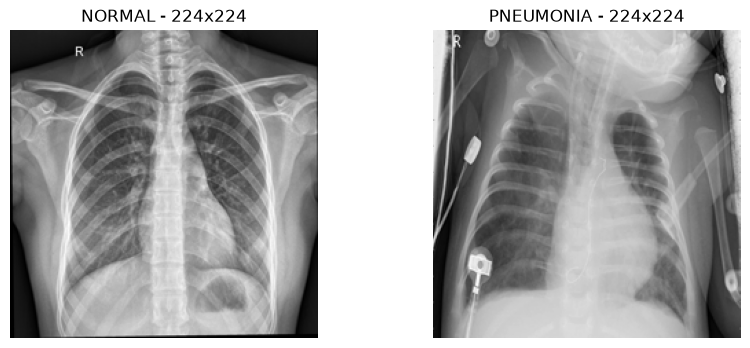

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(normal_resized, cmap="gray")
plt.title("NORMAL - 224x224")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia_resized, cmap="gray")
plt.title("PNEUMONIA - 224x224")
plt.axis("off")

plt.show()

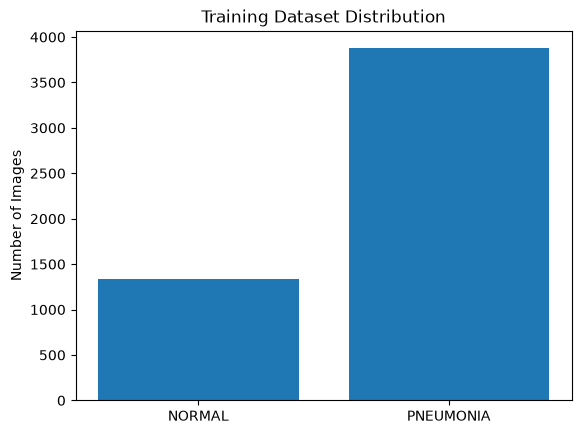

In [8]:
import matplotlib.pyplot as plt

labels = ["NORMAL", "PNEUMONIA"]
train_counts = [1341, 3875]

plt.bar(labels, train_counts)
plt.title("Training Dataset Distribution")
plt.ylabel("Number of Images")
plt.show()

In [9]:
import tensorflow as tf
from pathlib import Path

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [10]:
DATA_DIR = Path("../data/chest_xray")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 5216 files belonging to 2 classes.


In [12]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "val",
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [13]:
print("Classes:", train_ds.class_names)

Classes: ['NORMAL', 'PNEUMONIA']


In [14]:
images, labels = next(iter(train_ds))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Image shape: (32, 224, 224, 1)
Label shape: (32, 1)


In [15]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [16]:
images, labels = next(iter(train_ds))

print("Minimum:", tf.reduce_min(images).numpy())
print("Maximum:", tf.reduce_max(images).numpy())

Minimum: 0.0
Maximum: 1.0


In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [18]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


/Users/user/Desktop/LungAI/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  2/163 ━━━━━━━━━━━━━━━━━━━━ 21:55 8s/step - accuracy: 0.6562 - loss: 0.6646 

KeyboardInterrupt: 

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Test setindeki gerçek etiketler
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# Model tahminleri
y_prob = model.predict(test_ds)
y_pred = (y_prob.ravel() >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

# Görselleştir
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues")
plt.title("LungAI - Confusion Matrix")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Test setindeki gerçek etiketler
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# Model tahminleri
y_prob = model.predict(test_ds)
y_pred = (y_prob.ravel() >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

# Görselleştir
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues")
plt.title("LungAI - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Gerçek etiketler
y_true = np.concatenate([y.numpy() for x, y in test_ds])

# Model tahminleri
y_prob = model.predict(test_ds)
y_pred = (y_prob.ravel() >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Görselleştir
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("LungAI - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
print(class_weight_dict)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=np.array([0] * 1341 + [1] * 3875)
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
print(class_weight_dict)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

weighted_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

weighted_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

weighted_model.summary()

In [ ]:
history_weighted = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict
)

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.xticks([0, 1], ["NORMAL", "PNEUMONIA"])
plt.yticks([0, 1], ["NORMAL", "PNEUMONIA"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Weighted Model")

# Sayıları hücrelerin içine yaz
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [25]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

model_v2 = Sequential([
    Input(shape=(224, 224, 1)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model_v2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

y_true_v2 = []
y_pred_v2 = []

for images, labels in test_ds:
    predictions = model_v2.predict(images, verbose=0)

    y_true_v2.extend(labels.numpy())
    y_pred_v2.extend(
        (predictions > 0.5).astype(int).flatten()
    )

y_true_v2 = np.array(y_true_v2)
y_pred_v2 = np.array(y_pred_v2)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_v2,
    y_pred_v2,
    target_names=["NORMAL", "PNEUMONIA"]
))

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_v2 = confusion_matrix(y_true_v2, y_pred_v2)

print(cm_v2)

plt.figure(figsize=(6, 5))
plt.imshow(cm_v2)

plt.xticks([0, 1], ["NORMAL", "PNEUMONIA"])
plt.yticks([0, 1], ["NORMAL", "PNEUMONIA"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Model V2")

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            cm_v2[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
print("Tahmin sayısı:", len(y_pred_v2))
print("Gerçek etiket sayısı:", len(y_true_v2))

In [ ]:
print("TEST")

In [ ]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_ds)

print("V2 Test Loss:", test_loss_v2)
print("V2 Test Accuracy:", test_accuracy_v2)

In [ ]:
print("TEST")

In [ ]:
print("Jupyter çalışıyor")

In [ ]:
from pathlib import Path

list(Path("models").glob("*"))

In [26]:
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 909s 6s/step - accuracy: 0.7396 - loss: 0.5892 - val_accuracy: 0.5000 - val_loss: 0.7997
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 429s 3s/step - accuracy: 0.7490 - loss: 0.5103 - val_accuracy: 0.5625 - val_loss: 0.8351
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8390 - loss: 0.3436 - val_accuracy: 0.6250 - val_loss: 0.7576
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.8541 - loss: 0.3164 - val_accuracy: 0.5625 - val_loss: 1.0741
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8892 - loss: 0.2605 - val_accuracy: 0.6875 - val_loss: 0.9935
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.8903 - loss: 0.2599 - val_accuracy: 0.7500 - val_loss: 0.6539
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9036 - loss: 0.2366 - val_accuracy: 0.5625 - val_loss: 1.1936
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9135 - loss: 0.2147 - val_accu

In [27]:
from pathlib import Path

Path("models").mkdir(exist_ok=True)

model_v2.save("models/model_v2.keras")

print("Model kaydedildi!")

Model kaydedildi!


In [28]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_ds)

print("V2 Test Loss:", test_loss_v2)
print("V2 Test Accuracy:", test_accuracy_v2)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 305ms/step - accuracy: 0.6875 - loss: 0.9804
V2 Test Loss: 0.980351448059082
V2 Test Accuracy: 0.6875


In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model_v2.predict(test_ds)
y_pred = (y_prob >= 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 301ms/step
Confusion Matrix:
[[ 46 188]
 [  7 383]]


In [1]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [31]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

# Base model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Önceden eğitilmiş ağı şimdilik dondur
base_model.trainable = False

# Yeni model
inputs = tf.keras.Input(shape=(224, 224, 1))

# Grayscale → RGB
x = layers.Concatenate()([inputs, inputs, inputs])

# MobileNetV2'nin beklediği aralık
x = layers.Rescaling(scale=2.0, offset=-1.0)(x)

# Data augmentation
x = layers.RandomFlip("horizontal")(x)
x = layers.RandomRotation(0.05)(x)
x = layers.RandomZoom(0.1)(x)

# Pretrained CNN
x = base_model(x, training=False)

# Classifier
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_v3 = Model(inputs, outputs)

model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_v3.summary()

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5: None -- [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 1))

x = layers.Concatenate()([inputs, inputs, inputs])
x = layers.Rescaling(scale=2.0, offset=-1.0)(x)

x = layers.RandomFlip("horizontal")(x)
x = layers.RandomRotation(0.05)(x)
x = layers.RandomZoom(0.1)(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model_v3 = Model(inputs, outputs)

model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_v3.summary()

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5: None -- [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)

In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 hazır!")

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5: None -- [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)

In [5]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.load_weights("models/mobilenet_v2.h5")

base_model.trainable = False

print("MobileNetV2 hazır!")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'models/mobilenet_v2.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [6]:
import os

print(os.path.exists("models/mobilenet_v2.h5"))

False


In [7]:
import os

print(os.getcwd())

/Users/user/Desktop/LungAI/notebooks


In [8]:
from pathlib import Path

weights_path = Path("../models/mobilenet_v2.h5")

print(weights_path.exists())
print(weights_path.resolve())

True
/Users/user/Desktop/LungAI/models/mobilenet_v2.h5


In [9]:
base_model.load_weights(str(weights_path))

base_model.trainable = False

print("MobileNetV2 ağırlıkları başarıyla yüklendi!")

MobileNetV2 ağırlıkları başarıyla yüklendi!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

inputs = tf.keras.Input(shape=(224, 224, 1))

# Grayscale → 3 kanal
x = layers.Concatenate()([inputs, inputs, inputs])

# MobileNetV2 ImageNet ön işleme
x = layers.Rescaling(scale=2.0, offset=-1.0)(x)

# Data augmentation
x = layers.RandomFlip("horizontal")(x)
x = layers.RandomRotation(0.05)(x)
x = layers.RandomZoom(0.1)(x)

# Frozen MobileNetV2
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model_v3 = Model(inputs, outputs)

model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_v3.summary()

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model

inputs = tf.keras.Input(shape=(224, 224, 1))

# Grayscale → 3 kanal
x = layers.Concatenate()([inputs, inputs, inputs])

# MobileNetV2 ImageNet ön işleme
x = layers.Rescaling(scale=2.0, offset=-1.0)(x)

# Data augmentation
x = layers.RandomFlip("horizontal")(x)
x = layers.RandomRotation(0.05)(x)
x = layers.RandomZoom(0.1)(x)

# Frozen MobileNetV2
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model_v3 = Model(inputs, outputs)

model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_v3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_2[0]… │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ concatenate[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ random_zoom[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
class_weight_dict = {
    0: 1.9448173005219984,
    1: 0.6730322580645162
}

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7
)

history_v3 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr]
)

NameError: name 'train_ds' is not defined

In [13]:
from pathlib import Path
import tensorflow as tf

DATA_DIR = Path("../data/chest_xray")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=False
)

print("Train:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test:", tf.data.experimental.cardinality(test_ds).numpy())

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Train: 163
Validation: 1
Test: 20


In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [15]:
class_weight_dict = {
    0: 1.9448173005219984,
    1: 0.6730322580645162
}

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7
)

history_v3 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10


/Users/user/Desktop/LungAI/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 696ms/step - accuracy: 0.7918 - loss: 0.4394 - val_accuracy: 0.6875 - val_loss: 0.5478 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 574ms/step - accuracy: 0.8692 - loss: 0.3113 - val_accuracy: 0.6875 - val_loss: 0.5162 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 564ms/step - accuracy: 0.8794 - loss: 0.2849 - val_accuracy: 0.8125 - val_loss: 0.4965 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 567ms/step - accuracy: 0.8932 - loss: 0.2617 - val_accuracy: 0.6875 - val_loss: 0.4679 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 86s 524ms/step - accuracy: 0.8988 - loss: 0.2565 - val_accuracy: 0.6875 - val_loss: 0.4644 - learning_rate: 1.0000e-04
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 594ms/step - accuracy: 0.8970 - loss: 0.2558 - val_accuracy: 0.7500 - val_loss: 0.4456 - learning_rate: 1.0000e-04
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 580ms/step -

In [17]:
v3_test_loss, v3_test_accuracy = model_v3.evaluate(test_ds)

print("V3 Test Loss:", v3_test_loss)
print("V3 Test Accuracy:", v3_test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 314ms/step - accuracy: 0.7468 - loss: 0.5089
V3 Test Loss: 0.5089038014411926
V3 Test Accuracy: 0.7467948794364929


In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_v3.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions.flatten() >= 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm_v3 = confusion_matrix(y_true, y_pred)

print("V3 Confusion Matrix:")
print(cm_v3)

print("\nV3 Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"],
        digits=2
    )
)

V3 Confusion Matrix:
[[185  49]
 [109 281]]

V3 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.63      0.79      0.70       234
   PNEUMONIA       0.85      0.72      0.78       390

    accuracy                           0.75       624
   macro avg       0.74      0.76      0.74       624
weighted avg       0.77      0.75      0.75       624



In [22]:
# MobileNetV2'yi bul
base_model = model_v3.get_layer("mobilenetv2_1.00_224")

# Önce tamamını dondur
base_model.trainable = True

# Sadece son 30 katmanı eğit
for layer in base_model.layers[:-30]:
    layer.trainable = False

# BatchNormalization katmanlarını dondur
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Trainable layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

print("\nTrainable parameters:", 
      sum(tf.keras.backend.count_params(w) for w in model_v3.trainable_weights))

Trainable layers:
block_14_expand
block_14_expand_relu
block_14_depthwise
block_14_depthwise_relu
block_14_project
block_14_add
block_15_expand
block_15_expand_relu
block_15_depthwise
block_15_depthwise_relu
block_15_project
block_15_add
block_16_expand
block_16_expand_relu
block_16_depthwise
block_16_depthwise_relu
block_16_project
Conv_1
out_relu

Trainable parameters: 1674817


In [23]:
model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping_ft = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=1,
    min_lr=1e-7
)

In [29]:
history_v3_ft = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weight_dict,
    callbacks=[
        early_stopping_ft,
        reduce_lr_ft
    ]
)

Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 617ms/step - accuracy: 0.9279 - loss: 0.1726 - val_accuracy: 0.8750 - val_loss: 0.3099 - learning_rate: 1.0000e-07
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 612ms/step - accuracy: 0.9270 - loss: 0.1794 - val_accuracy: 0.8750 - val_loss: 0.3068 - learning_rate: 1.0000e-07
Epoch 3/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 602ms/step - accuracy: 0.9321 - loss: 0.1680 - val_accuracy: 0.8750 - val_loss: 0.3081 - learning_rate: 1.0000e-07
Epoch 4/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 643ms/step - accuracy: 0.9312 - loss: 0.1761 - val_accuracy: 0.8750 - val_loss: 0.3070 - learning_rate: 1.0000e-07


In [30]:
model_v3.save("models/lungai_v3_finetuned.keras")

In [31]:
v3_ft_loss, v3_ft_accuracy = model_v3.evaluate(test_ds)

print("V3 Fine-Tuned Test Loss:", v3_ft_loss)
print("V3 Fine-Tuned Test Accuracy:", v3_ft_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 424ms/step - accuracy: 0.7933 - loss: 0.4395
V3 Fine-Tuned Test Loss: 0.43945810198783875
V3 Fine-Tuned Test Accuracy: 0.7932692170143127


In [32]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true_ft = []
y_pred_ft = []

for images, labels in test_ds:
    predictions = model_v3(images, training=False).numpy().flatten()

    y_true_ft.extend(labels.numpy().flatten())
    y_pred_ft.extend((predictions >= 0.5).astype(int))

y_true_ft = np.array(y_true_ft)
y_pred_ft = np.array(y_pred_ft)

cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

print("V3 Fine-Tuned Confusion Matrix:")
print(cm_ft)

print("\nV3 Fine-Tuned Classification Report:")
print(
    classification_report(
        y_true_ft,
        y_pred_ft,
        target_names=["NORMAL", "PNEUMONIA"],
        digits=2
    )
)

V3 Fine-Tuned Confusion Matrix:
[[162  72]
 [ 57 333]]

V3 Fine-Tuned Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.74      0.69      0.72       234
   PNEUMONIA       0.82      0.85      0.84       390

    accuracy                           0.79       624
   macro avg       0.78      0.77      0.78       624
weighted avg       0.79      0.79      0.79       624



In [33]:
model_v3.save("models/lungai_v3_finetuned.keras")
print("V3 Fine-Tuned model kaydedildi!")

V3 Fine-Tuned model kaydedildi!


In [34]:
import os

for split in ["train", "val", "test"]:
    split_path = os.path.join("../data/chest_xray", split)

    print(f"\n--- {split.upper()} ---")

    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_path = os.path.join(split_path, class_name)

        if os.path.exists(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            print(f"{class_name}: {count}")
        else:
            print(f"{class_name}: KLASÖR YOK")


--- TRAIN ---
NORMAL: 1341
PNEUMONIA: 3875

--- VAL ---
NORMAL: 8
PNEUMONIA: 8

--- TEST ---
NORMAL: 234
PNEUMONIA: 390


In [35]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = "../data/chest_xray/train"
test_dir = "../data/chest_xray/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.10,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.10,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 5216 files belonging to 2 classes.
Using 4695 files for training.
Found 5216 files belonging to 2 classes.
Using 521 files for validation.
Found 624 files belonging to 2 classes.
Train batches: 147
Validation batches: 17
Test batches: 20


In [36]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

IMG_SIZE = (224, 224)

# Input: grayscale
inputs = layers.Input(shape=(224, 224, 1))

# Grayscale -> RGB
x = layers.Concatenate()([inputs, inputs, inputs])

# MobileNetV2 preprocessing
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)

# Data augmentation
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="augmentation")

x = augmentation(x)

# Pretrained MobileNetV2
base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

# Load the weights you downloaded
base_model.load_weights("../models/mobilenet_v2.h5")

# Freeze initially
base_model.trainable = False

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model_v4 = Model(inputs, outputs)

model_v4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_v4.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_3[0]… │
│                     │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ concatenate_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ rescaling_1[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ augmentation[0][… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [37]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-7
    )
]

history_v4 = model_v4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/8


/Users/user/Desktop/LungAI/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


147/147 ━━━━━━━━━━━━━━━━━━━━ 98s 636ms/step - accuracy: 0.8034 - loss: 0.4175 - val_accuracy: 0.9251 - val_loss: 0.1954 - learning_rate: 1.0000e-04
Epoch 2/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 79s 532ms/step - accuracy: 0.9086 - loss: 0.2261 - val_accuracy: 0.9386 - val_loss: 0.1574 - learning_rate: 1.0000e-04
Epoch 3/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 80s 537ms/step - accuracy: 0.9242 - loss: 0.1832 - val_accuracy: 0.9443 - val_loss: 0.1416 - learning_rate: 1.0000e-04
Epoch 4/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 95s 643ms/step - accuracy: 0.9350 - loss: 0.1600 - val_accuracy: 0.9539 - val_loss: 0.1294 - learning_rate: 1.0000e-04
Epoch 5/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 80s 541ms/step - accuracy: 0.9423 - loss: 0.1487 - val_accuracy: 0.9539 - val_loss: 0.1226 - learning_rate: 1.0000e-04
Epoch 6/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 84s 565ms/step - accuracy: 0.9457 - loss: 0.1374 - val_accuracy: 0.9578 - val_loss: 0.1146 - learning_rate: 1.0000e-04
Epoch 7/8
147/147 ━━━━━━━━━━━━━━━━━━━━ 92s 624ms/step - accura

In [38]:
print("Best Validation Accuracy:",
      max(history_v4.history["val_accuracy"]))

print("Best Validation Loss:",
      min(history_v4.history["val_loss"]))

Best Validation Accuracy: 0.9635316729545593
Best Validation Loss: 0.11452536284923553


In [39]:
# MobileNetV2'nin son 30 katmanını fine-tuning için aç
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Çok düşük learning rate
model_v4.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_v4.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_3[0]… │
│                     │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ concatenate_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ rescaling_1[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ augmentation[0][… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 1,690,497 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [40]:
history_v4_ft = model_v4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=1,
            min_lr=1e-7
        )
    ]
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 129s 838ms/step - accuracy: 0.9233 - loss: 0.2278 - val_accuracy: 0.9635 - val_loss: 0.1018 - learning_rate: 1.0000e-05
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 102s 691ms/step - accuracy: 0.9378 - loss: 0.1466 - val_accuracy: 0.9674 - val_loss: 0.0912 - learning_rate: 1.0000e-05
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 121s 818ms/step - accuracy: 0.9472 - loss: 0.1369 - val_accuracy: 0.9674 - val_loss: 0.0901 - learning_rate: 1.0000e-05
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 110s 742ms/step - accuracy: 0.9544 - loss: 0.1117 - val_accuracy: 0.9674 - val_loss: 0.0942 - learning_rate: 1.0000e-05
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 104s 702ms/step - accuracy: 0.9548 - loss: 0.1154 - val_accuracy: 0.9655 - val_loss: 0.0961 - learning_rate: 3.0000e-06
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 101s 681ms/step - accuracy: 0.9531 - loss: 0.1130 - val_accuracy: 0.9597 - val_loss: 0.1016 - learning_rate: 9.0000e-07


In [41]:
test_loss, test_accuracy = model_v4.evaluate(test_ds)

print("V4 FINAL Test Loss:", test_loss)
print("V4 FINAL Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 326ms/step - accuracy: 0.8670 - loss: 0.3575
V4 FINAL Test Loss: 0.3574519157409668
V4 FINAL Test Accuracy: 0.8669871687889099


In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.concatenate([
    y.numpy().flatten()
    for _, y in test_ds
])

y_prob = model_v4.predict(test_ds).flatten()

y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

print("V4 FINAL Confusion Matrix:")
print(cm)

print("\nV4 FINAL Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 458ms/step
V4 FINAL Confusion Matrix:
[[157  77]
 [  6 384]]

V4 FINAL Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.67      0.79       234
   PNEUMONIA       0.83      0.98      0.90       390

    accuracy                           0.87       624
   macro avg       0.90      0.83      0.85       624
weighted avg       0.88      0.87      0.86       624



In [43]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Validation gerçek etiketleri
y_val_true = np.concatenate([
    y.numpy().flatten()
    for _, y in val_ds
])

# Validation olasılıkları
y_val_prob = model_v4.predict(val_ds).flatten()

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.30, 0.71, 0.01):
    y_val_pred = (y_val_prob >= threshold).astype(int)

    score = f1_score(
        y_val_true,
        y_val_pred,
        average="macro"
    )

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best Validation Macro F1:", best_f1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 419ms/step
Best Threshold: 0.5700000000000003
Best Validation Macro F1: 0.48128991525217946


In [44]:
val_ds_fixed = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.10,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Using 521 files for validation.


In [45]:
y_val_true = np.concatenate([
    y.numpy().flatten()
    for _, y in val_ds_fixed
])

y_val_prob = model_v4.predict(val_ds_fixed).flatten()

print("Images:", len(y_val_true))
print("Predictions:", len(y_val_prob))

17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 494ms/step
Images: 521
Predictions: 521


In [46]:
from sklearn.metrics import f1_score

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.30, 0.71, 0.01):
    y_pred = (y_val_prob >= threshold).astype(int)

    score = f1_score(
        y_val_true,
        y_pred,
        average="macro"
    )

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best Validation Macro F1:", best_f1)

Best Threshold: 0.3
Best Validation Macro F1: 0.49319066147859925


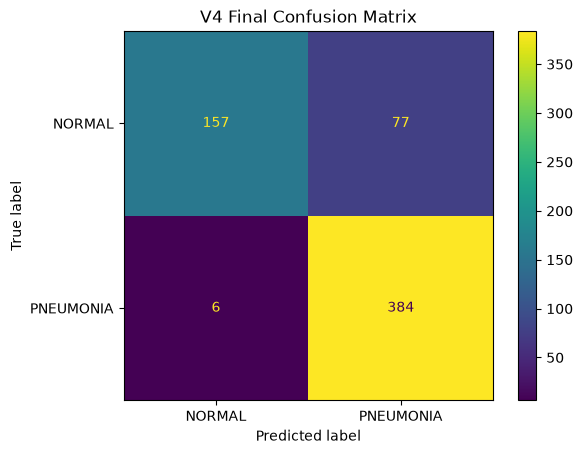

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
).plot()

plt.title("V4 Final Confusion Matrix")
plt.show()

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

ValueError: Found input variables with inconsistent numbers of samples: [624, 521, 624]

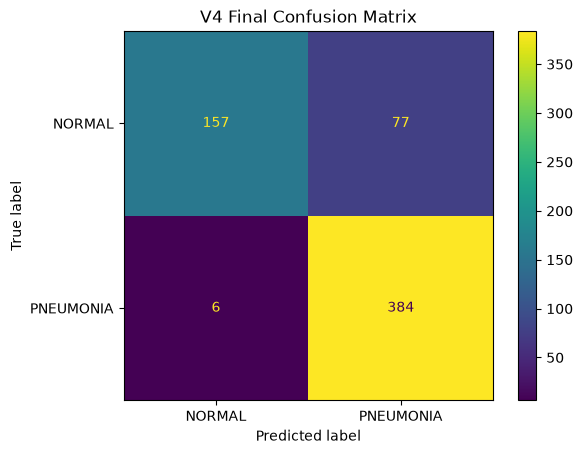

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
).plot()

plt.title("V4 Final Confusion Matrix")
plt.show()

In [50]:
# V4 final modelini kaydet
model_v4.save("models/LungAI_V4_final.keras")

print("V4 model başarıyla kaydedildi.")

V4 model başarıyla kaydedildi.


In [51]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Test tahminleri
y_true = np.concatenate([y.numpy().flatten() for _, y in test_ds])
y_prob = model_v4.predict(test_ds).flatten()

print("\nThreshold | NORMAL Recall | PNEUMONIA Recall | Accuracy")
print("-" * 58)

for threshold in np.arange(0.30, 0.71, 0.05):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    normal_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
    pneumonia_recall = cm[1, 1] / (cm[1, 0] + cm[1, 1])
    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()

    print(
        f"{threshold:.2f}      | "
        f"{normal_recall:.3f}         | "
        f"{pneumonia_recall:.3f}            | "
        f"{accuracy:.3f}"
    )

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 419ms/step

Threshold | NORMAL Recall | PNEUMONIA Recall | Accuracy
----------------------------------------------------------
0.30      | 0.598         | 0.995            | 0.846
0.35      | 0.615         | 0.992            | 0.851
0.40      | 0.637         | 0.990            | 0.857
0.45      | 0.650         | 0.990            | 0.862
0.50      | 0.671         | 0.985            | 0.867
0.55      | 0.679         | 0.982            | 0.869
0.60      | 0.688         | 0.982            | 0.872
0.65      | 0.731         | 0.977            | 0.885
0.70      | 0.761         | 0.972            | 0.893


In [52]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score

# =========================
# 1. VALIDATION PREDICTIONS
# =========================

y_val_true = np.concatenate([
    y.numpy().flatten()
    for _, y in val_ds_fixed
])

y_val_prob = model_v4.predict(val_ds_fixed, verbose=0).flatten()

# =========================
# 2. FIND BEST THRESHOLD
# =========================

results = []

for threshold in np.arange(0.30, 0.81, 0.01):
    y_val_pred = (y_val_prob >= threshold).astype(int)

    cm = confusion_matrix(y_val_true, y_val_pred)

    normal_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
    pneumonia_recall = cm[1, 1] / (cm[1, 0] + cm[1, 1])
    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
    macro_f1 = f1_score(
        y_val_true,
        y_val_pred,
        average="macro"
    )

    results.append(
        (
            threshold,
            normal_recall,
            pneumonia_recall,
            accuracy,
            macro_f1
        )
    )

# PNEUMONIA recall en az %95 olacak şekilde
# en yüksek macro F1'ı seç
valid_results = [
    r for r in results
    if r[2] >= 0.95
]

best = max(valid_results, key=lambda x: x[4])

best_threshold = best[0]

print("BEST VALIDATION THRESHOLD")
print("-------------------------")
print(f"Threshold:          {best[0]:.2f}")
print(f"NORMAL Recall:      {best[1]:.3f}")
print(f"PNEUMONIA Recall:   {best[2]:.3f}")
print(f"Accuracy:           {best[3]:.3f}")
print(f"Macro F1:           {best[4]:.3f}")

# =========================
# 3. FINAL TEST EVALUATION
# =========================

y_test_true = np.concatenate([
    y.numpy().flatten()
    for _, y in test_ds
])

y_test_prob = model_v4.predict(test_ds, verbose=0).flatten()

y_test_pred = (y_test_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_test_true, y_test_pred)

normal_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
pneumonia_recall = cm[1, 1] / (cm[1, 0] + cm[1, 1])
accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
macro_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="macro"
)

print("\nFINAL TEST RESULT")
print("-----------------")
print(f"Threshold:          {best_threshold:.2f}")
print(f"NORMAL Recall:      {normal_recall:.3f}")
print(f"PNEUMONIA Recall:   {pneumonia_recall:.3f}")
print(f"Accuracy:           {accuracy:.3f}")
print(f"Macro F1:           {macro_f1:.3f}")

print("\nConfusion Matrix:")
print(cm)

/var/folders/gf/fksx_0n14j7ddcnm_kwfxsxh0000gn/T/ipykernel_63225/2931092046.py:26: RuntimeWarning: invalid value encountered in scalar divide
  normal_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
/var/folders/gf/fksx_0n14j7ddcnm_kwfxsxh0000gn/T/ipykernel_63225/2931092046.py:26: RuntimeWarning: invalid value encountered in scalar divide
  normal_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
/var/folders/gf/fksx_0n14j7ddcnm_kwfxsxh0000gn/T/ipykernel_63225/2931092046.py:26: RuntimeWarning: invalid value encountered in scalar divide
  normal_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
/var/folders/gf/fksx_0n14j7ddcnm_kwfxsxh0000gn/T/ipykernel_63225/2931092046.py:26: RuntimeWarning: invalid value encountered in scalar divide
  normal_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
/var/folders/gf/fksx_0n14j7ddcnm_kwfxsxh0000gn/T/ipykernel_63225/2931092046.py:26: RuntimeWarning: invalid value encountered in scalar divide
  normal_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
/var/folders/gf/fksx_0n14j7ddcnm_kw

BEST VALIDATION THRESHOLD
-------------------------
Threshold:          0.30
NORMAL Recall:      nan
PNEUMONIA Recall:   0.973
Accuracy:           0.973
Macro F1:           0.493

FINAL TEST RESULT
-----------------
Threshold:          0.30
NORMAL Recall:      0.598
PNEUMONIA Recall:   0.995
Accuracy:           0.846
Macro F1:           0.817

Confusion Matrix:
[[140  94]
 [  2 388]]


In [53]:
print("Unique validation labels:")
print(np.unique(y_val_true, return_counts=True))

print("\nModel probability range:")
print("Min:", y_val_prob.min())
print("Max:", y_val_prob.max())

print("\nFirst 20 labels:")
print(y_val_true[:20])

print("\nFirst 20 probabilities:")
print(y_val_prob[:20])

Unique validation labels:
(array([1], dtype=int32), array([521]))

Model probability range:
Min: 0.013472126
Max: 0.99999905

First 20 labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

First 20 probabilities:
[0.9998788  0.99999434 0.9948725  0.9999824  0.99572885 0.955995
 0.99568933 0.99997663 0.9999898  0.9999846  0.9993034  0.9999584
 0.9996418  0.9994286  0.99978274 0.99074435 0.9997601  0.08712329
 0.9997714  0.99239385]


In [54]:
print(train_dir)
print(test_dir)

../data/chest_xray/train
../data/chest_xray/test


In [55]:
import tensorflow as tf

val_ds_fixed = tf.keras.utils.image_dataset_from_directory(
    "../data/chest_xray/val",
    image_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
)

print("Validation batches:", tf.data.experimental.cardinality(val_ds_fixed).numpy())

print(
    "Validation class counts:",
    np.unique(
        np.concatenate([y.numpy().flatten() for _, y in val_ds_fixed]),
        return_counts=True
    )
)

Found 16 files belonging to 2 classes.
Validation batches: 1
Validation class counts: (array([0, 1], dtype=int32), array([8, 8]))


In [56]:
import tensorflow as tf
import numpy as np

val_ds_threshold = tf.keras.utils.image_dataset_from_directory(
    "../data/chest_xray/train",
    validation_split=0.10,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
)

y_check = np.concatenate([
    y.numpy().flatten()
    for _, y in val_ds_threshold
])

print("Validation images:", len(y_check))
print("Class distribution:", np.unique(y_check, return_counts=True))

Found 5216 files belonging to 2 classes.
Using 521 files for validation.
Validation images: 521
Class distribution: (array([1], dtype=int32), array([521]))


In [57]:
import os
import glob
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# =========================
# 1. IMAGE PATHS
# =========================

normal_paths = glob.glob("../data/chest_xray/train/NORMAL/*")
pneumonia_paths = glob.glob("../data/chest_xray/train/PNEUMONIA/*")

# 134 NORMAL + 387 PNEUMONIA = 521 görüntü
np.random.seed(42)

normal_val = np.random.choice(normal_paths, 134, replace=False)
pneumonia_val = np.random.choice(pneumonia_paths, 387, replace=False)

val_paths = np.concatenate([normal_val, pneumonia_val])
val_labels = np.concatenate([
    np.zeros(134, dtype=np.int32),
    np.ones(387, dtype=np.int32)
])

# Karıştır
indices = np.random.permutation(len(val_paths))
val_paths = val_paths[indices]
val_labels = val_labels[indices]

# =========================
# 2. CREATE DATASET
# =========================

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32)
    return image, label

val_ds_threshold = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_ds_threshold = (
    val_ds_threshold
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================
# 3. CHECK
# =========================

print("Validation images:", len(val_paths))
print("NORMAL:", np.sum(val_labels == 0))
print("PNEUMONIA:", np.sum(val_labels == 1))

Validation images: 521
NORMAL: 134
PNEUMONIA: 387


In [58]:
from sklearn.metrics import confusion_matrix, f1_score
import numpy as np

# =========================
# VALIDATION PREDICTIONS
# =========================

y_val_true = np.concatenate([
    y.numpy().flatten()
    for _, y in val_ds_threshold
])

y_val_prob = model_v4.predict(
    val_ds_threshold,
    verbose=1
).flatten()

# =========================
# THRESHOLD SEARCH
# =========================

best_threshold = None
best_score = -1
best_info = None

print("\nThreshold | NORMAL Recall | PNEUMONIA Recall | Accuracy | Macro F1")
print("-" * 70)

for threshold in np.arange(0.30, 0.81, 0.01):

    y_pred = (y_val_prob >= threshold).astype(int)

    cm = confusion_matrix(
        y_val_true,
        y_pred,
        labels=[0, 1]
    )

    normal_recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
    pneumonia_recall = cm[1, 1] / (cm[1, 0] + cm[1, 1])

    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()

    macro_f1 = f1_score(
        y_val_true,
        y_pred,
        average="macro"
    )

    # PNEUMONIA recall en az %95
    if pneumonia_recall >= 0.95:

        # Öncelik: Macro F1
        if macro_f1 > best_score:
            best_score = macro_f1
            best_threshold = threshold

            best_info = (
                normal_recall,
                pneumonia_recall,
                accuracy,
                macro_f1
            )

    # Sadece önemli thresholdları göster
    if threshold in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
        print(
            f"{threshold:.2f}      | "
            f"{normal_recall:.3f}         | "
            f"{pneumonia_recall:.3f}            | "
            f"{accuracy:.3f}    | "
            f"{macro_f1:.3f}"
        )

print("\n==============================")
print("BEST VALIDATION THRESHOLD")
print("==============================")

print(f"Threshold:        {best_threshold:.2f}")
print(f"NORMAL Recall:    {best_info[0]:.3f}")
print(f"PNEUMONIA Recall: {best_info[1]:.3f}")
print(f"Accuracy:         {best_info[2]:.3f}")
print(f"Macro F1:         {best_info[3]:.3f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 420ms/step

Threshold | NORMAL Recall | PNEUMONIA Recall | Accuracy | Macro F1
----------------------------------------------------------------------
0.30      | 0.925         | 0.977            | 0.964    | 0.952

BEST VALIDATION THRESHOLD
Threshold:        0.60
NORMAL Recall:    0.948
PNEUMONIA Recall: 0.972
Accuracy:         0.965
Macro F1:         0.955


In [59]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)
import numpy as np

# =========================
# FINAL TEST PREDICTION
# =========================

y_test_true = np.concatenate([
    y.numpy().flatten()
    for _, y in test_ds
])

y_test_prob = model_v4.predict(
    test_ds,
    verbose=1
).flatten()

# Validation'dan seçtiğimiz threshold
FINAL_THRESHOLD = 0.60

y_test_pred = (
    y_test_prob >= FINAL_THRESHOLD
).astype(int)

# =========================
# FINAL METRICS
# =========================

cm = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=[0, 1]
)

accuracy = accuracy_score(
    y_test_true,
    y_test_pred
)

macro_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="macro"
)

print("\n================================")
print("V4 FINAL THRESHOLD TEST")
print("================================")

print(f"Threshold: {FINAL_THRESHOLD:.2f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Macro F1:  {macro_f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=["NORMAL", "PNEUMONIA"],
        digits=4
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 419ms/step

V4 FINAL THRESHOLD TEST
Threshold: 0.60
Accuracy:  0.8718
Macro F1:  0.8532

Confusion Matrix:
[[161  73]
 [  7 383]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9583    0.6880    0.8010       234
   PNEUMONIA     0.8399    0.9821    0.9054       390

    accuracy                         0.8718       624
   macro avg     0.8991    0.8350    0.8532       624
weighted avg     0.8843    0.8718    0.8663       624



<Figure size 700x600 with 0 Axes>

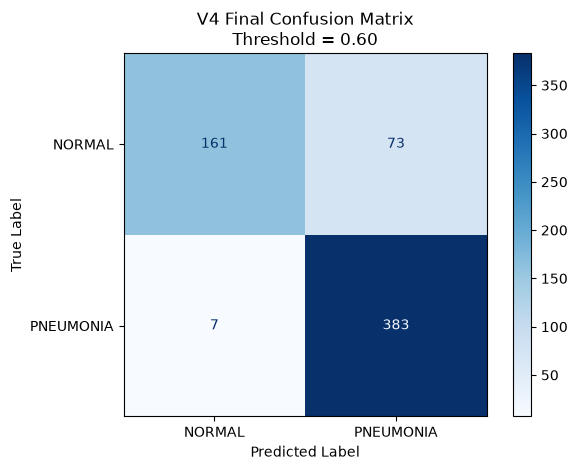

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
).plot(cmap="Blues", values_format="d")

plt.title("V4 Final Confusion Matrix\nThreshold = 0.60")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(
    "models/V4_final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

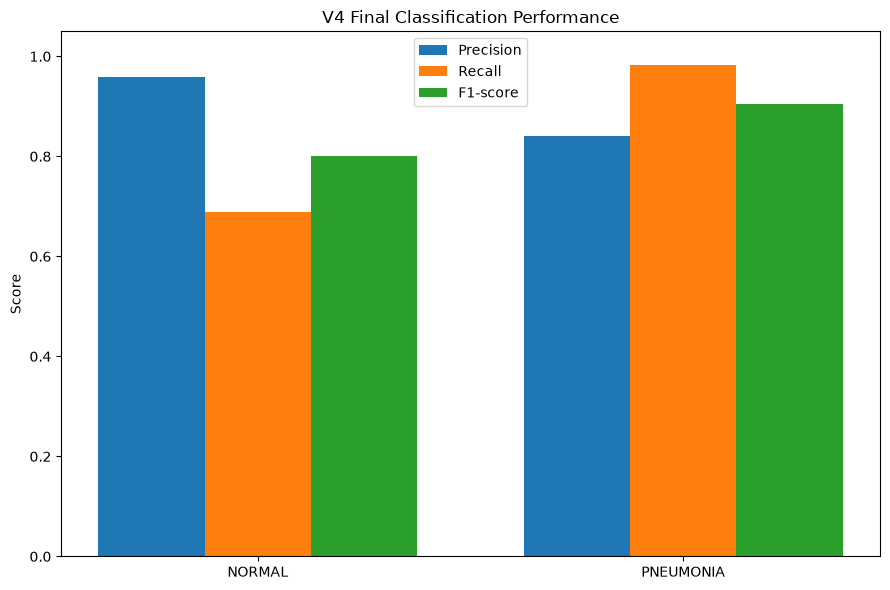

In [61]:
import matplotlib.pyplot as plt
import numpy as np

classes = ["NORMAL", "PNEUMONIA"]

precision = [0.9583, 0.8399]
recall = [0.6880, 0.9821]
f1 = [0.8010, 0.9054]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(9, 6))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, classes)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("V4 Final Classification Performance")
plt.legend()

plt.tight_layout()

plt.savefig(
    "models/V4_final_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

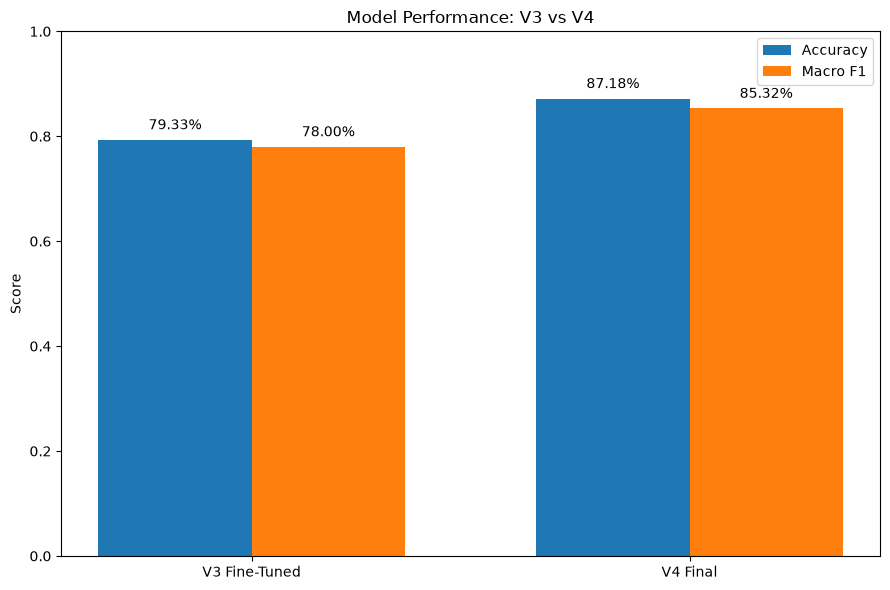

In [62]:
import matplotlib.pyplot as plt
import numpy as np

models = ["V3 Fine-Tuned", "V4 Final"]

accuracy = [0.7933, 0.8718]
macro_f1 = [0.78, 0.8532]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    accuracy,
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    macro_f1,
    width,
    label="Macro F1"
)

plt.xticks(x, models)
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.title("Model Performance: V3 vs V4")
plt.legend()

# Değerleri sütunların üzerine yaz
for i, value in enumerate(accuracy):
    plt.text(
        i - width / 2,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

for i, value in enumerate(macro_f1):
    plt.text(
        i + width / 2,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "models/V3_vs_V4_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

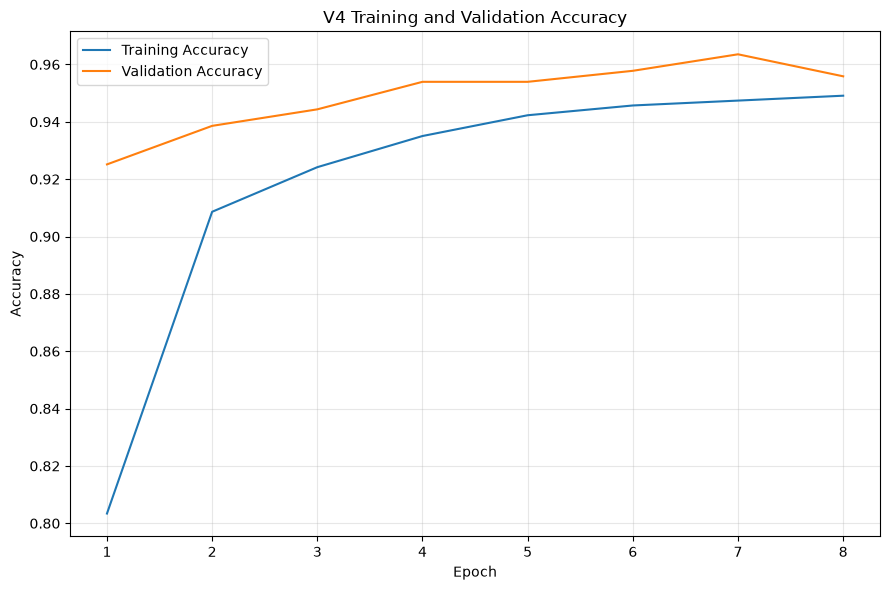

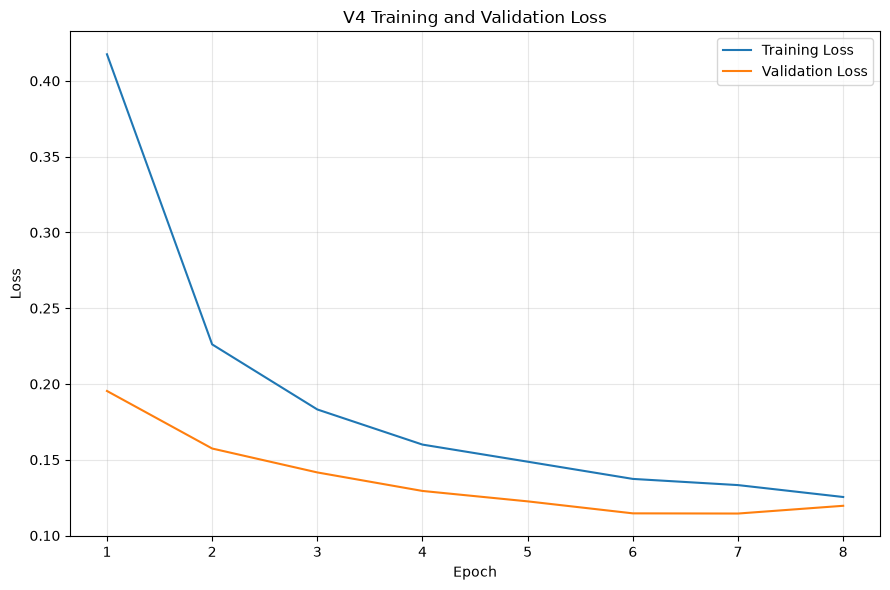

In [63]:
import matplotlib.pyplot as plt

# =========================
# V4 TRAINING HISTORY
# =========================

history = history_v4.history

epochs = range(1, len(history["accuracy"]) + 1)

# -------------------------
# Accuracy
# -------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    epochs,
    history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("V4 Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "models/V4_training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------
# Loss
# -------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    epochs,
    history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("V4 Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "models/V4_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
model_v4.save("models/LungAI_V4.keras")

In [65]:
ls -lh models/

total 143120
-rw-r--r--  1 user  staff    23M Aug 28 16:31 LungAI_V4.keras
-rw-r--r--  1 user  staff    23M Aug 28 16:16 LungAI_V4_final.keras
-rw-r--r--  1 user  staff    80K Aug 28 16:27 V3_vs_V4_comparison.png
-rw-r--r--  1 user  staff    75K Aug 28 16:26 V4_final_confusion_matrix.png
-rw-r--r--  1 user  staff    68K Aug 28 16:27 V4_final_metrics.png
-rw-r--r--  1 user  staff   135K Aug 28 16:28 V4_training_accuracy.png
-rw-r--r--  1 user  staff   125K Aug 28 16:28 V4_training_loss.png
-rw-r--r--  1 user  staff    23M Aug 28 15:37 lungai_v3_finetuned.keras
-rw-r--r--  1 user  staff   1.3M Aug 26 23:40 model_v2.keras
